<a href="https://colab.research.google.com/github/eyaaaaamb/Classification-ML/blob/main/tp2_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy





In [ ]:
df=pd.read_csv("/content/sample_data/DATA_1.csv")

In [ ]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Diabetic
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [ ]:
print(df.groupby('Diabetic').size())

Diabetic
0    500
1    268
dtype: int64


In [ ]:
df["Diabetic"].value_counts()

,count
Diabetic,
0,500
1,268


<Axes: xlabel='Diabetic', ylabel='count'>

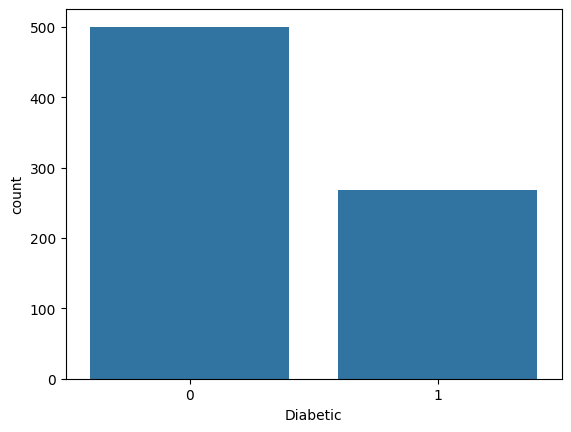

In [ ]:
sns.countplot(x="Diabetic",data=df)

array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Diabetic'}>]], dtype=object)

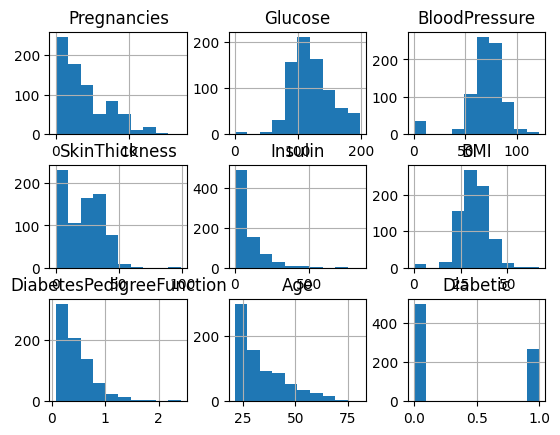

In [ ]:
df.hist()

<Axes: xlabel='Age', ylabel='count'>

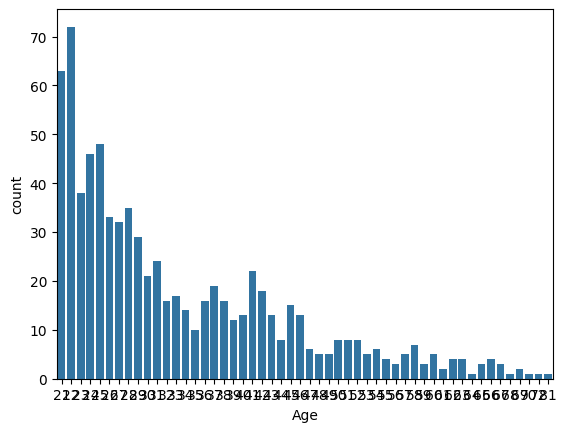

In [ ]:
sns.countplot(x="Age",data=df)



In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Diabetic,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x=df.drop("Diabetic",axis=1)
y=df["Diabetic"]

In [ ]:
Xtrain,Xtest,Ytrain,Ytest=train_test_split(x,y,test_size=0.3,random_state=42,stratify=df['Diabetic'])


In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
my_tree=DecisionTreeClassifier()

In [ ]:
my_tree.fit(Xtrain,Ytrain)

DecisionTreeClassifier()

In [ ]:
my_tree.score(Xtest,Ytest)

0.7402597402597403

In [ ]:
p=my_tree.get_params()
for param,valeur in p.items():
  print(param,":",valeur)


ccp_alpha : 0.0
class_weight : None
criterion : gini
max_depth : None
max_features : None
max_leaf_nodes : None
min_impurity_decrease : 0.0
min_samples_leaf : 1
min_samples_split : 2
min_weight_fraction_leaf : 0.0
monotonic_cst : None
random_state : None
splitter : best


In [ ]:
my_tree2=DecisionTreeClassifier(criterion="entropy")


In [ ]:
my_tree2.fit(Xtrain,Ytrain)
my_tree2.score(Xtest,Ytest)

0.7316017316017316

In [ ]:
my_tree3=DecisionTreeClassifier(max_depth=5)
my_tree3.fit(Xtrain,Ytrain)
my_tree3.score(Xtest,Ytest)


0.7705627705627706

In [ ]:
my_tree4=DecisionTreeClassifier(min_samples_leaf=3,max_depth=5,)
my_tree4.fit(Xtrain,Ytrain)
my_tree4.score(Xtest,Ytest)

0.7575757575757576

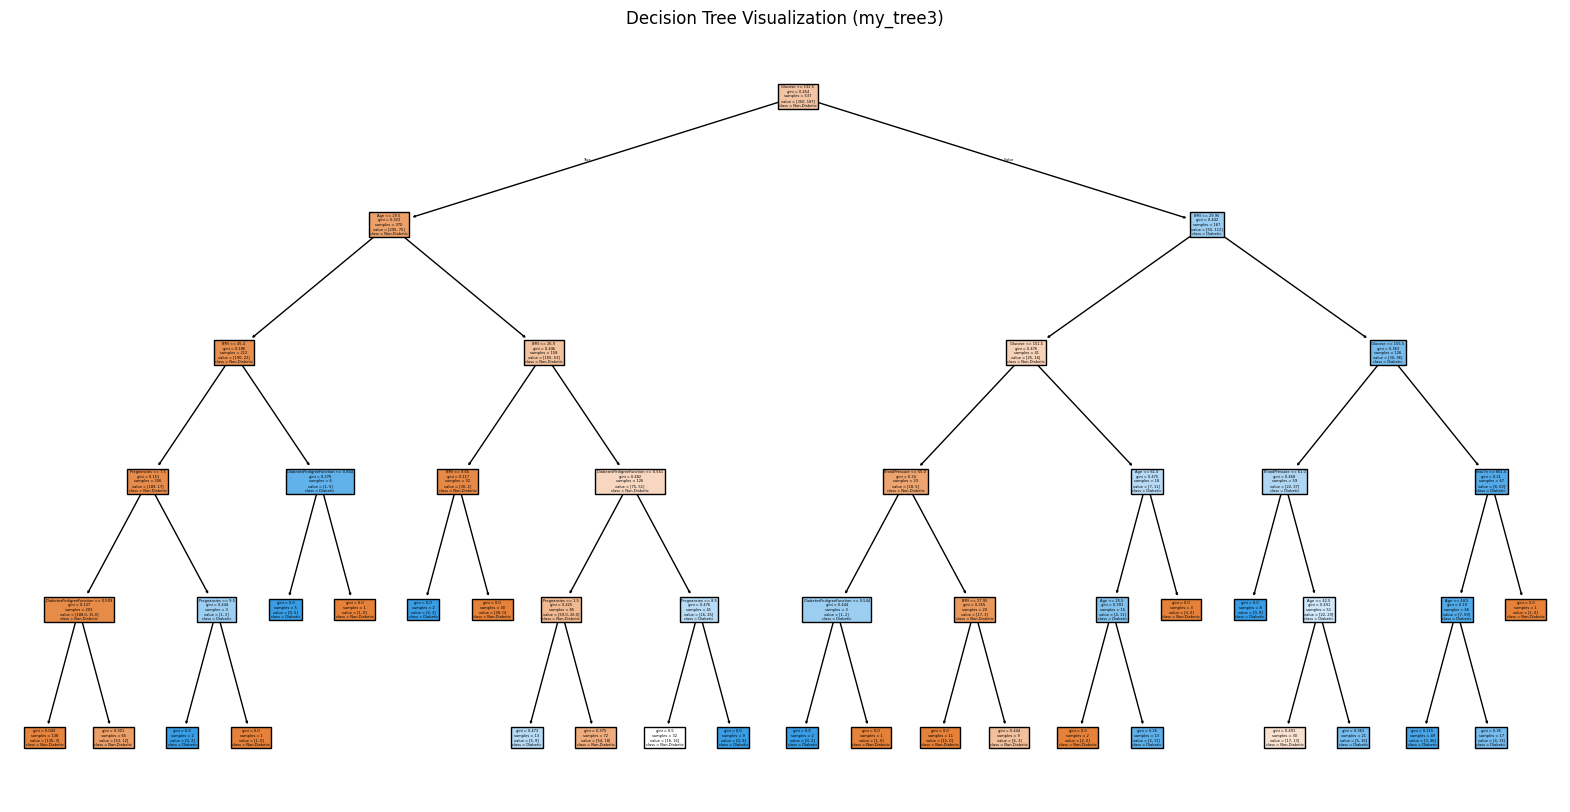

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(my_tree3, filled=True, feature_names=x.columns, class_names=['Non-Diabetic', 'Diabetic'])
plt.title('Decision Tree Visualization (my_tree3)')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Define the parameter grid to search
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

# Fit GridSearchCV to the training data
grid_search.fit(Xtrain, Ytrain)

# Display the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score found: ", grid_search.best_score_)

# You can also access the best estimator directly
best_dt_model = grid_search.best_estimator_
print("\nBest Decision Tree Classifier:\n", best_dt_model)

# Evaluate the best model on the test set
test_score = best_dt_model.score(Xtest, Ytest)
print(f"\nAccuracy of the best model on the test set: {test_score}")

Fitting 3 folds for each of 160 candidates, totalling 480 fits
Best parameters found:  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best accuracy score found:  0.7392923649906891

Best Decision Tree Classifier:
 DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

Accuracy of the best model on the test set: 0.7316017316017316


In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
rf=RandomForestClassifier()

In [ ]:
rf.fit(Xtrain,Ytrain)
rf.score(Xtest,Ytest)

0.7532467532467533

In [ ]:
params_rf=rf.get_params()
for param,valeur in params_rf.items():
  print(param,":",valeur)

bootstrap : True
ccp_alpha : 0.0
class_weight : None
criterion : gini
max_depth : None
max_features : sqrt
max_leaf_nodes : None
max_samples : None
min_impurity_decrease : 0.0
min_samples_leaf : 1
min_samples_split : 2
min_weight_fraction_leaf : 0.0
monotonic_cst : None
n_estimators : 100
n_jobs : None
oob_score : False
random_state : None
verbose : 0
warm_start : False


In [ ]:
mytree1=RandomForestClassifier()
gridParams={
      "n_estimators": [50, 100, 200],           # Number of trees
    "max_depth": [None, 5, 10, 15],           # Maximum depth of each tree
    "min_samples_split": [2, 5, 10],          # Minimum samples to split a node
    "min_samples_leaf": [1, 2, 4],            # Minimum samples at a leaf node
    "max_features": ["sqrt", "log2", None],   # Number of features considered at each split
    "bootstrap": [True, False]                # Whether to use bootstrap samples



}
grid=GridSearchCV(mytree1,gridParams,cv=5)
grid.fit(Xtrain,Ytrain)
print(grid.best_params_)
print(grid.best_score_)

{'bootstrap': True, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
0.7709588092765663


k-nearest neighbor exercice :

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
my_tree6=KNeighborsClassifier()
my_tree6.fit(Xtrain,Ytrain)
my_tree6.score(Xtest,Ytest)

0.7186147186147186

In [ ]:
df.shape

(768, 9)

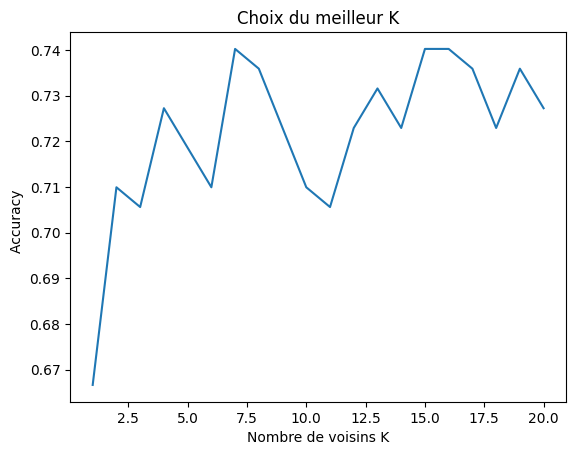

In [ ]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

K_values = range(1, 21)
scores = []

for k in K_values:
    mytree = KNeighborsClassifier(n_neighbors=k)
    mytree.fit(Xtrain, Ytrain)
    score=mytree.score(Xtest,Ytest)
    scores.append(score)

# Affichage
plt.plot(K_values, scores)
plt.xlabel('Nombre de voisins K')
plt.ylabel('Accuracy  ')
plt.title('Choix du meilleur K')
plt.show()


In [ ]:
my_tree8=KNeighborsClassifier(n_neighbors=15)
my_tree8.fit(Xtrain,Ytrain)
my_tree8.score(Xtest,Ytest)

0.7402597402597403

In [ ]:
my_tree88=KNeighborsClassifier(n_neighbors=7)
my_tree88.fit(Xtrain,Ytrain)
my_tree88.score(Xtest,Ytest)

0.7402597402597403

In [ ]:
my_tree10=KNeighborsClassifier()
params_rf=my_tree10.get_params()
for param,valeur in params_rf.items():
  print(param,":",valeur)

algorithm : auto
leaf_size : 30
metric : minkowski
metric_params : None
n_jobs : None
n_neighbors : 5
p : 2
weights : uniform


In [ ]:
my_tree9=KNeighborsClassifier()
gridParams={
    "n_neighbors":[1,3,4,5,11,14,7,15,12,2],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"],
    "p":[1,2],
    "algorithm":["auto","ball_tree","kd_tree","brute"],
    "leaf_size":[10,20,30],
    "n_jobs":[None,-1],

}
grid=GridSearchCV(my_tree9,gridParams,cv=5)
grid.fit(Xtrain,Ytrain)
print(grid.best_params_)
print(grid.best_score_)

{'algorithm': 'auto', 'leaf_size': 10, 'metric': 'manhattan', 'n_jobs': None, 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
0.7523710626514364


takes long time
{'algorithm': 'auto', 'leaf_size': 10, 'metric': 'manhattan', 'n_jobs': None, 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
0.7523710626514364
